In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import download_prices, get_log_prices
from src.signals_rolling import (
    rolling_hedge_ratio,
    compute_rolling_spread,
    compute_rolling_zscore,
    generate_positions,
)
from src.backtest import run_backtest
from src.metrics import summarize_results

## Data Loading

In [2]:
tickers = ["KO", "PEP"]
start = "2015-01-01"
end = "2022-12-31"

prices = download_prices(tickers, start=start, end=end)
lp = get_log_prices(prices)

prices.head()


[*********************100%***********************]  2 of 2 completed


Ticker,KO,PEP
Date,,
2015-01-02,29.390255,66.582939
2015-01-05,29.390255,66.082359
2015-01-06,29.613436,65.581787
2015-01-07,29.983086,67.499466
2015-01-08,30.345755,68.726242


## Backtesting the Strategy

In [3]:
window = 60
entry = 2.0
exit = 0.5
tc_rate = 0.0002 # costs may be lower as PEP/KO are high liquidity stocks, so trading costs may be lesser
slippage_rate = 0.0005

In [4]:
hedge_ratios = rolling_hedge_ratio(lp, window=window)

spread = compute_rolling_spread(lp, hedge_ratios)

zscore = compute_rolling_zscore(spread, window=window)

positions = generate_positions(zscore, entry=entry, exit=exit)

In [5]:
results = run_backtest(
    prices=prices,
    positions=positions,
    hedge_ratios=hedge_ratios,
    tc_rate=tc_rate,
    slippage_rate=slippage_rate,
)

results.tail()

,positions,daily_pnl,cum_pnl,trading_costs,y_units,x_units
Date,,,,,,
2022-12-23,1,0.750458,-16.449712,0.000421,1,-0.656122
2022-12-27,1,0.488338,-15.961374,0.000553,1,-0.642467
2022-12-28,1,-0.802765,-16.764139,0.000844,1,-0.621425
2022-12-29,1,-0.009310,-16.773449,0.000692,1,-0.604284
2022-12-30,1,-0.987993,-17.761442,0.000607,1,-0.589155


In [6]:
summary = summarize_results(results)
summary

{'total_pnl': -17.76144216347106,
 'sharpe': -0.20861219693456481,
 'max_drawdown': -35.2464727670707,
 'num_trades': 87}

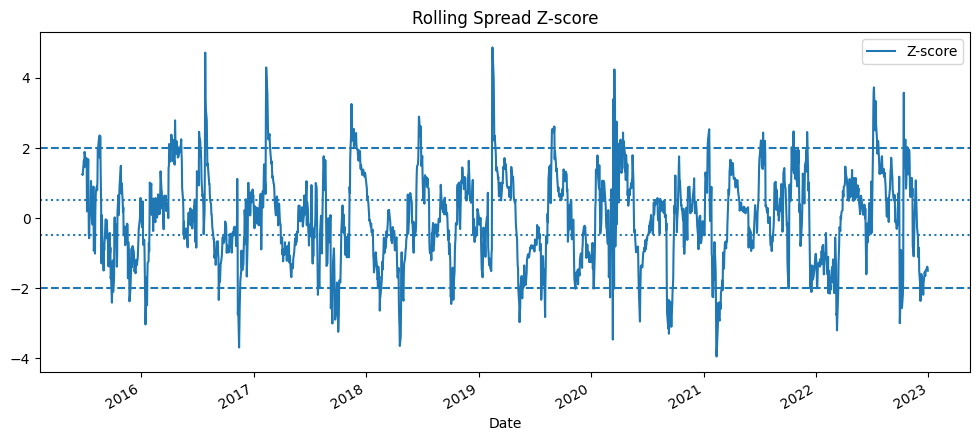

In [7]:
plt.figure(figsize=(12, 5))
zscore.plot(label="Z-score")
plt.axhline(entry, linestyle="--")
plt.axhline(-entry, linestyle="--")
plt.axhline(exit, linestyle=":")
plt.axhline(-exit, linestyle=":")
plt.title("Rolling Spread Z-score")
plt.legend()
plt.show()

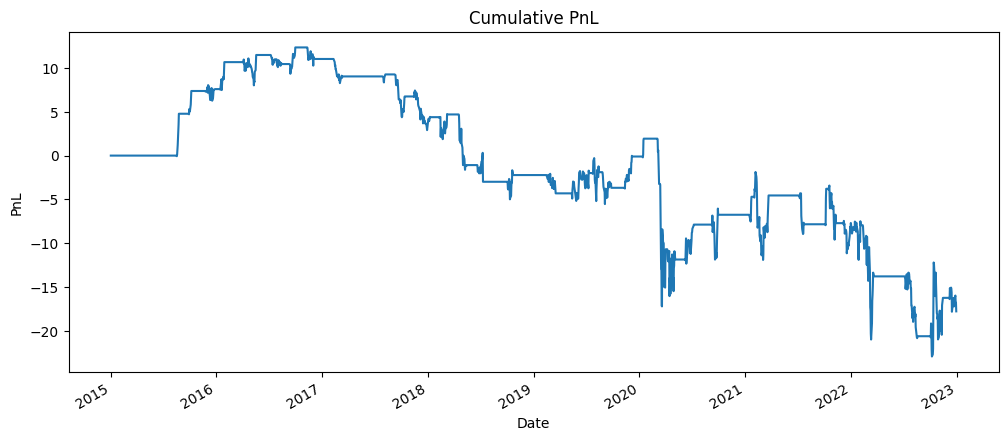

In [8]:
plt.figure(figsize=(12, 5))
results["cum_pnl"].plot()
plt.title("Cumulative PnL")
plt.ylabel("PnL")
plt.show()

## Grid search for better hyperparameters 

In [9]:
experiments = []

for window in [30, 60, 90, 120]:
    for entry in [1.5, 2.0, 2.5]:
        hedge_ratios = rolling_hedge_ratio(lp, window=window)
        spread = compute_rolling_spread(lp, hedge_ratios)
        zscore = compute_rolling_zscore(spread, window=window)
        positions = generate_positions(zscore, entry=entry, exit=0.5)

        results = run_backtest(
            prices=prices,
            positions=positions,
            hedge_ratios=hedge_ratios,
            tc_rate=tc_rate,
            slippage_rate=slippage_rate,
        )

        summary = summarize_results(results)
        summary["window"] = window
        summary["entry"] = entry
        summary["exit"] = 0.5

        experiments.append(summary)

experiment_results = pd.DataFrame(experiments)
experiment_results.sort_values("sharpe", ascending=False)

,total_pnl,sharpe,max_drawdown,num_trades,window,entry,exit
5,-6.091576,-0.092229,-22.435743,50,60,2.5,0.5
4,-17.761442,-0.208612,-35.246473,87,60,2.0,0.5
3,-25.511727,-0.274002,-39.669419,119,60,1.5,0.5
2,-17.369645,-0.309027,-28.828161,74,30,2.5,0.5
6,-30.871226,-0.330259,-44.196704,91,90,1.5,0.5
11,-23.897225,-0.364076,-41.915217,34,120,2.5,0.5
1,-26.917200,-0.385059,-42.036976,140,30,2.0,0.5
10,-31.300531,-0.400069,-42.812638,50,120,2.0,0.5
9,-41.942571,-0.465264,-61.284598,72,120,1.5,0.5
0,-45.737049,-0.512191,-69.422746,232,30,1.5,0.5


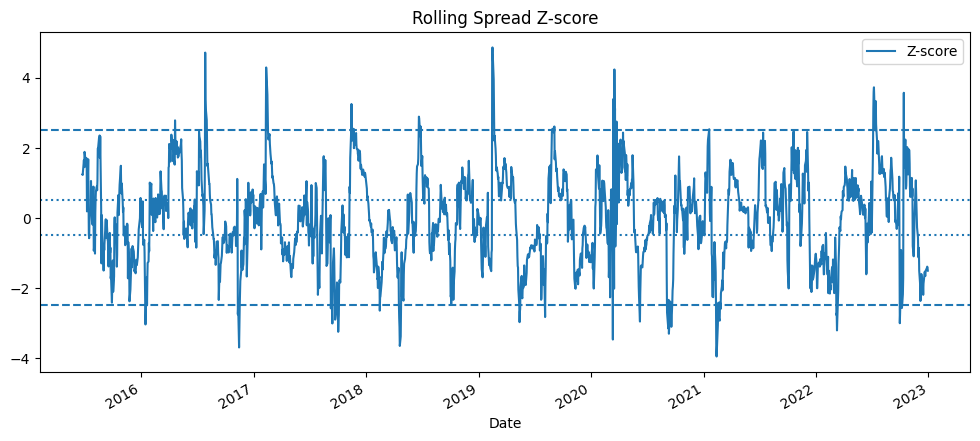

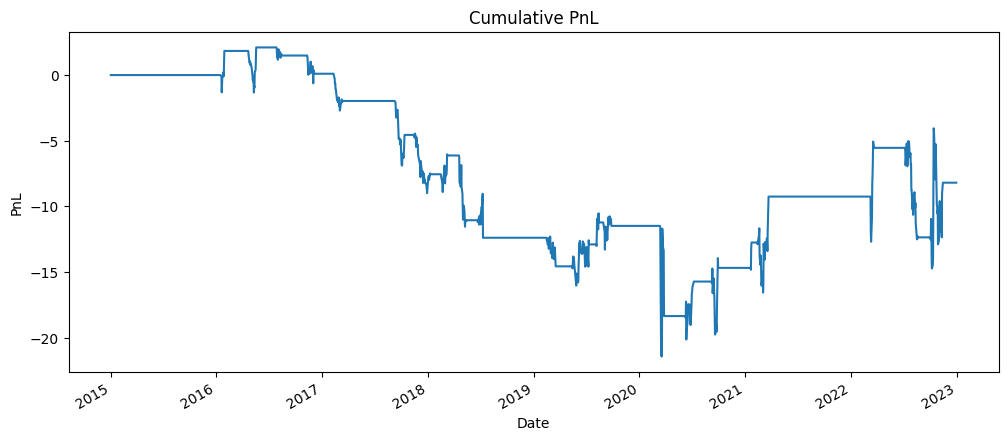

{'total_pnl': -8.191187695304967,
 'sharpe': -0.12389171464698324,
 'max_drawdown': -23.524162743328663,
 'num_trades': 50}

In [10]:
window = 60
entry = 2.5
exit = 0.5
tc_rate = 0.0005
slippage_rate = 0.0005

hedge_ratios = rolling_hedge_ratio(lp, window=window)
spread = compute_rolling_spread(lp, hedge_ratios)
zscore = compute_rolling_zscore(spread, window=window)
positions = generate_positions(zscore, entry=entry, exit=exit)

results = run_backtest(
    prices=prices, positions=positions,
    hedge_ratios=hedge_ratios, tc_rate=tc_rate, slippage_rate=slippage_rate,
)

plt.figure(figsize=(12, 5))
zscore.plot(label="Z-score")
plt.axhline(entry, linestyle="--")
plt.axhline(-entry, linestyle="--")
plt.axhline(exit, linestyle=":")
plt.axhline(-exit, linestyle=":")
plt.title("Rolling Spread Z-score")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
results["cum_pnl"].plot()
plt.title("Cumulative PnL")
plt.ylabel("PnL")
plt.show()

summary = summarize_results(results)
summary


### Investigating the sudden spike
found it was because of the sudden spike in PEP (2020-03-12) after longing the spread and also a sudden drop in it (2020-03-19) after shorting the spread

In [11]:
results.loc["2020-03-09":"2020-03-24"]

,positions,daily_pnl,cum_pnl,trading_costs,y_units,x_units
Date,,,,,,
2020-03-09,0,0.000000,-11.480039,0.000000,0,-0.000000
2020-03-10,0,0.000000,-11.480039,0.000000,0,-0.000000
2020-03-11,0,0.000000,-11.480039,0.000000,0,-0.000000
2020-03-12,0,0.000000,-11.480039,0.000000,0,-0.000000
2020-03-13,1,-0.138955,-11.618994,0.138955,1,-0.850677
2020-03-16,0,-9.672841,-21.291835,0.124885,0,-0.000000
2020-03-17,0,0.000000,-21.291835,0.000000,0,-0.000000
2020-03-18,-1,-0.129093,-21.420928,0.129093,-1,0.798375
2020-03-19,-1,0.946269,-20.474659,0.001195,-1,0.763885


In [12]:
prices.loc["2020-03-09":"2020-03-24"]

Ticker,KO,PEP
Date,,
2020-03-09,42.571850,107.039658
2020-03-10,44.049469,110.312691
2020-03-11,42.859165,106.702477
2020-03-12,38.713623,94.852127
2020-03-13,40.137962,104.811020
2020-03-16,37.479752,93.001785
2020-03-17,39.069702,105.033081
2020-03-18,37.140217,99.440941
2020-03-19,34.639370,96.496864
